# ML-bike: predicting city-bike trip duration from calendar and weather

**Goal:** predict how long a city-bike trip takes, given when it starts and what the weather is like.

**ML problem formulation**
- **Data point:** one bike trip.
- **Features:** weekday, hour of day, month, daily mean temperature, daily precipitation.
- **Label:** trip duration in minutes (a positive real number → regression).
- **Hypothesis spaces:** linear models on one-hot encoded calendar features, and gradient-boosted regression trees.
- **Loss:** this is the methodological core of the project. Bike-share duration data has extreme outliers — a rider forgets to end the rental and the "trip" lasts all night. Squared error weights those outliers by the *square* of their error, so a handful of them can dominate the fit. We therefore compare squared error against two robust losses, **Huber** and **absolute error (LAD)**, and select on mean absolute error.
- **Validation:** time-based split. Train on 2022–2023, validate on 2024, test on 2025.

**Data**
- `data/YYYY-MM.csv` — trips from the Helsinki & Espoo city-bike system, seasons April–October 2022–2025.
- `data/weather_daily.csv` — daily mean temperature and precipitation from the Finnish Meteorological Institute (FMI) open data, station Helsinki Kaisaniemi. Step 3 shows how it was downloaded.

Steps:
1. Setup
2. Load the trips
3. Load the weather
4. Merge and clean
5. Explore: the outlier problem
6. Explore: what the features tell us
7. Features and train/validation/test split
8. Models: one hypothesis space, three losses
9. Why the loss matters: an outlier-sensitivity experiment
10. Final evaluation on the test set
11. Conclusions

## 1. Setup

In [1]:
import ssl
import urllib.parse
import urllib.request
import xml.etree.ElementTree as ET
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import HuberRegressor, LinearRegression, SGDRegressor
from sklearn.metrics import (
    mean_absolute_error,
    median_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

DATA_DIR = Path("data")
WEATHER_CSV = DATA_DIR / "weather_daily.csv"
RANDOM_STATE = 42

# Target: switch to "distance_km" to predict distance instead; everything below still works.
TARGET = "duration_min"

pd.set_option("display.float_format", "{:,.2f}".format)
plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 2. Load the trips

The monthly files all share the same columns. We need the departure time (for the calendar features and for joining weather by date), the duration (our label) and the distance (to filter out false starts, and as an alternative label).

In [2]:
COLUMNS = {
    "Departure": "departure",
    "Covered distance (m)": "distance_m",
    "Duration (sec.)": "duration_s",
}

files = sorted(p for p in DATA_DIR.glob("[0-9]*.csv"))
print(f"Found {len(files)} monthly trip files")

frames = []
for f in files:
    month_df = pd.read_csv(
        f,
        usecols=list(COLUMNS),
        dtype={"Covered distance (m)": "float32", "Duration (sec.)": "float32"},
    ).rename(columns=COLUMNS)
    frames.append(month_df)

trips = pd.concat(frames, ignore_index=True)
del frames

# A few rows hold only a date with no time of day; they become NaT and are dropped in step 4.
trips["departure"] = pd.to_datetime(trips["departure"], format="%Y-%m-%dT%H:%M:%S", errors="coerce")

print(f"Loaded {len(trips):,} trips")
trips.head()

Found 28 monthly trip files
Loaded 10,121,026 trips


,departure,distance_m,duration_s
0,2022-04-30 23:59:53,"1,204.00","128,982.00"
1,2022-04-30 23:59:39,559.00,284.00
2,2022-04-30 23:59:19,"2,199.00","1,078.00"
3,2022-04-30 23:59:03,"1,933.00",590.00
4,2022-04-30 23:58:55,"1,208.00",477.00


## 3. Load the weather

`data/weather_daily.csv` holds daily observations from FMI's open data WFS API (station Helsinki Kaisaniemi, `fmisid=100971`):
- `tday` → `temp_c`, daily mean temperature in °C
- `rrday` → `precip_mm`, daily precipitation in mm

FMI reports **-1 mm** when no measurable precipitation fell, so we clip those to 0.

The cell below downloads the file if it is missing, so the notebook can be rerun from scratch. Daily weather is a compromise: hourly observations would match trips better, but a daily join is exactly the "minimal joining" this project needs, and rain on a given day is a reasonable proxy for cycling conditions.

In [3]:
FMISID = 100971  # Helsinki Kaisaniemi


def download_weather(path: Path, years=range(2022, 2026)) -> None:
    import certifi  # provides CA certificates; some Python installs cannot verify TLS without it

    context = ssl.create_default_context(cafile=certifi.where())
    ns = "{http://xml.fmi.fi/schema/wfs/2.0}"
    frames = []

    for year in years:
        query = urllib.parse.urlencode({
            "service": "WFS",
            "version": "2.0.0",
            "request": "getFeature",
            "storedquery_id": "fmi::observations::weather::daily::simple",
            "fmisid": FMISID,
            "starttime": f"{year}-04-01T00:00:00Z",
            "endtime": f"{year}-10-31T23:59:59Z",
            "parameters": "tday,rrday",
        })
        with urllib.request.urlopen(f"https://opendata.fmi.fi/wfs?{query}", timeout=120, context=context) as r:
            root = ET.fromstring(r.read())

        rows = [
            {
                "time": el.findtext(f"{ns}Time"),
                "name": el.findtext(f"{ns}ParameterName"),
                "value": pd.to_numeric(el.findtext(f"{ns}ParameterValue"), errors="coerce"),
            }
            for el in root.iter(f"{ns}BsWfsElement")
        ]
        wide = pd.DataFrame(rows).pivot_table(index="time", columns="name", values="value", aggfunc="first")
        wide.index = pd.to_datetime(wide.index).tz_convert(None).normalize()
        frames.append(wide)
        print(f"  downloaded {year}: {len(wide)} days")

    out = pd.concat(frames).sort_index().rename(columns={"tday": "temp_c", "rrday": "precip_mm"})
    out.index.name = "date"
    out[["temp_c", "precip_mm"]].to_csv(path, float_format="%.1f")


if not WEATHER_CSV.exists():
    print("Downloading weather from FMI open data...")
    download_weather(WEATHER_CSV)

weather = pd.read_csv(WEATHER_CSV, parse_dates=["date"]).set_index("date").sort_index()
weather["precip_mm"] = weather["precip_mm"].clip(lower=0)  # -1 means "no measurable rain"

print(f"{len(weather)} days, {weather.index.min().date()} -> {weather.index.max().date()}")
print(f"Rainy days (>= 0.1 mm): {(weather['precip_mm'] >= 0.1).mean():.1%}")
weather.describe()

856 days, 2022-04-01 -> 2025-10-31
Rainy days (>= 0.1 mm): 39.6%


,temp_c,precip_mm
count,856.00,856.00
mean,13.03,1.89
std,5.85,4.87
min,-2.00,0.00
25%,8.80,0.00
50%,13.75,0.00
75%,17.62,1.20
max,24.90,43.10


## 4. Merge and clean

We join weather onto trips by calendar date, then apply a **minimal** cleaning rule: drop missing values and false starts (under 10 seconds or under 10 metres — a bike undocked and immediately re-docked).

We deliberately **keep the long trips**. Deleting them would be the easy way to make squared error behave, but it throws away real data and needs an arbitrary cut-off. Handling them with a robust loss is the choice this project defends.

In [4]:
n_raw = len(trips)

trips = trips.dropna(subset=["departure", "duration_s", "distance_m"])
trips["date"] = trips["departure"].dt.normalize()
trips = trips.merge(weather, left_on="date", right_index=True, how="left")

no_weather = trips["temp_c"].isna()
print(f"Trips with no matching weather day: {no_weather.sum():,}")
trips = trips[~no_weather]

false_start = (trips["duration_s"] < 10) | (trips["distance_m"] < 10)
trips = trips[~false_start].reset_index(drop=True)

trips["duration_min"] = trips["duration_s"] / 60
trips["distance_km"] = trips["distance_m"] / 1000

print(f"Raw trips:        {n_raw:,}")
print(f"After cleaning:   {len(trips):,} ({len(trips) / n_raw:.1%})")
trips[["duration_min", "distance_km", "temp_c", "precip_mm"]].describe()

Trips with no matching weather day: 0
Raw trips:        10,121,026
After cleaning:   9,838,616 (97.2%)


,duration_min,distance_km,temp_c,precip_mm
count,"9,838,616.00","9,838,616.00","9,838,616.00","9,838,616.00"
mean,19.18,2.55,14.77,1.42
std,267.80,2.77,5.28,4.08
min,0.17,0.01,-2.00,0.00
25%,6.40,1.16,11.00,0.00
50%,10.85,1.99,15.70,0.00
75%,18.28,3.34,18.50,0.60
max,"279,454.31","3,681.01",24.90,43.10


## 5. Explore: the outlier problem

This step motivates the choice of loss, so it is worth looking at carefully.

In [5]:
d = trips["duration_min"]
q = d.quantile([0.5, 0.9, 0.99, 0.999, 0.9999])

print(f"mean      {d.mean():8.1f} min")
print(f"median    {d.median():8.1f} min")
for level, value in q.items():
    print(f"p{level * 100:<8g} {value:8.1f} min")
print(f"max       {d.max():8.1f} min  ({d.max() / 60:.1f} hours)")
print()
print(f"Trips over 5 hours:  {(d > 300).sum():>8,}  ({(d > 300).mean():.3%} of trips)")
print(f"Trips over 24 hours: {(d > 1440).sum():>8,}  ({(d > 1440).mean():.4%} of trips)")

# How much of the total squared error around the mean comes from that tiny tail?
sq_error = (d - d.mean()) ** 2
tail = d > 300
abs_error = (d - d.median()).abs()
print(f"\nTrips over 5 hours are {tail.mean():.3%} of the data, and they contribute:")
print(f"  {sq_error[tail].sum() / sq_error.sum():>6.1%} of the total squared error around the mean")
print(f"  {abs_error[tail].sum() / abs_error.sum():>6.1%} of the total absolute error around the median")

mean          19.2 min
median        10.9 min
p50           10.9 min
p90           27.6 min
p99           78.2 min
p99.9       1082.2 min
p99.99      5496.4 min
max       279454.3 min  (4657.6 hours)

Trips over 5 hours:    28,873  (0.293% of trips)
Trips over 24 hours:    5,553  (0.0564% of trips)

Trips over 5 hours are 0.293% of the data, and they contribute:
   99.7% of the total squared error around the mean
   36.0% of the total absolute error around the median


This printout is the argument for a robust loss. Under squared error, the ~0.3% of trips lasting over five hours account for almost **all** of the total error being minimised — so a model fitted this way is, in effect, fitted to forgotten rentals. Under absolute error the same trips carry roughly a third of the weight: much less, but still far more than their 0.3% share.

That second number is a useful warning. Absolute error is more robust, not immune, so MAE alone can still be swayed by the tail. This is why we also report the **median** absolute error, which describes the typical trip and is unaffected by how extreme the extremes are.

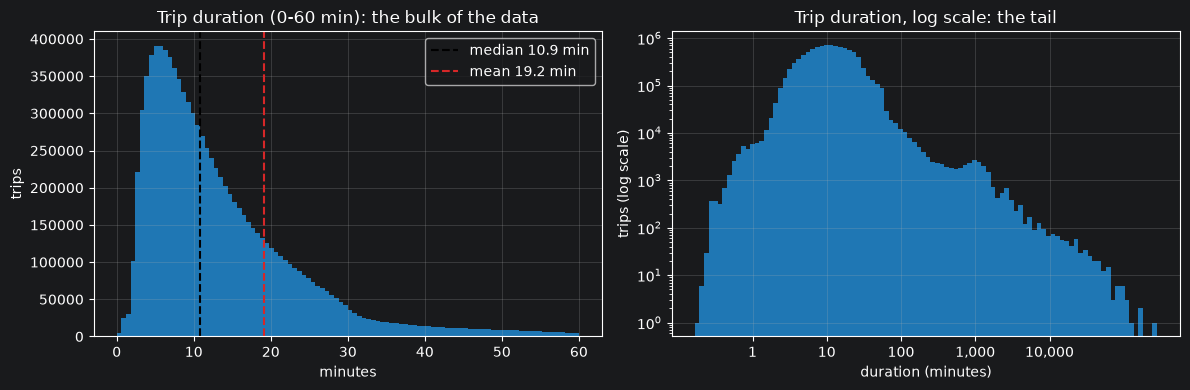

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(d, bins=100, range=(0, 60), color="tab:blue")
axes[0].axvline(d.median(), color="black", ls="--", label=f"median {d.median():.1f} min")
axes[0].axvline(d.mean(), color="tab:red", ls="--", label=f"mean {d.mean():.1f} min")
axes[0].set_title("Trip duration (0-60 min): the bulk of the data")
axes[0].set_xlabel("minutes")
axes[0].set_ylabel("trips")
axes[0].legend()

axes[1].hist(np.log10(d), bins=100, color="tab:blue")
axes[1].set_title("Trip duration, log scale: the tail")
axes[1].set_xlabel("duration (minutes)")
axes[1].set_xticks([0, 1, 2, 3, 4], ["1", "10", "100", "1,000", "10,000"])
axes[1].set_yscale("log")
axes[1].set_ylabel("trips (log scale)")

plt.tight_layout()
plt.show()

The mean sits clearly to the right of the median: the tail drags it. A model fitted with squared error predicts something close to a conditional **mean**, so it inherits that bias. A model fitted with absolute error predicts a conditional **median**, which describes a typical trip far better.

## 6. Explore: what the features tell us

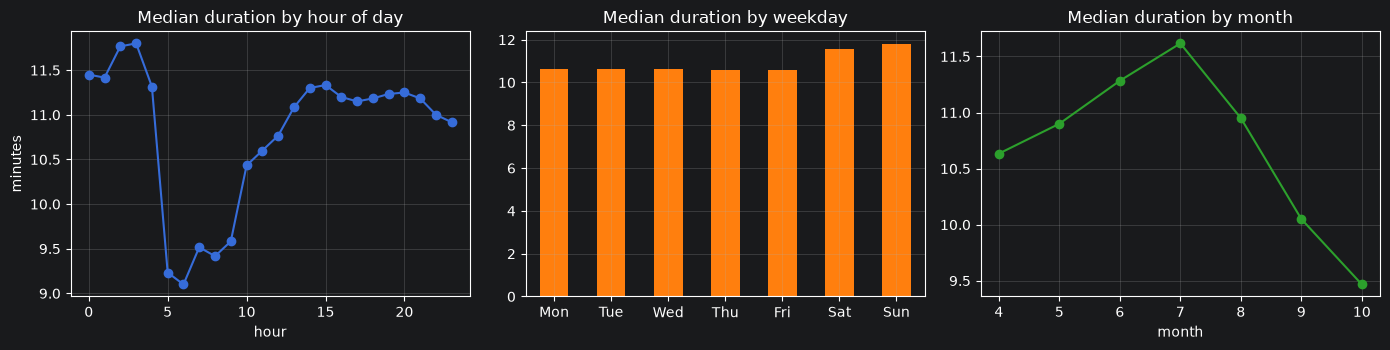

In [7]:
# Median is used throughout this section: it describes the typical trip and ignores the tail.
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))

trips.groupby(trips["departure"].dt.hour)["duration_min"].median().plot(ax=axes[0], marker="o")
axes[0].set_title("Median duration by hour of day")
axes[0].set_xlabel("hour")
axes[0].set_ylabel("minutes")

by_weekday = trips.groupby(trips["departure"].dt.dayofweek)["duration_min"].median()
by_weekday.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
by_weekday.plot(kind="bar", ax=axes[1], color="tab:orange")
axes[1].set_title("Median duration by weekday")
axes[1].tick_params(axis="x", rotation=0)

trips.groupby(trips["departure"].dt.month)["duration_min"].median().plot(ax=axes[2], marker="o", color="tab:green")
axes[2].set_title("Median duration by month")
axes[2].set_xlabel("month")

plt.tight_layout()
plt.show()

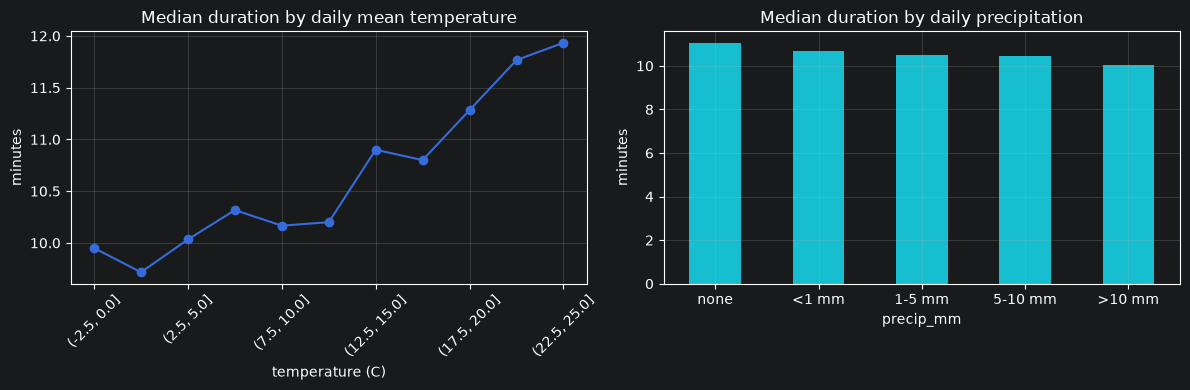

,median_duration,trips
precip_mm,,
none,11.03,6481829
<1 mm,10.67,1211079
1-5 mm,10.52,1368519
5-10 mm,10.43,350650
>10 mm,10.02,426539


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

temp_bins = pd.cut(trips["temp_c"], bins=np.arange(-5, 30, 2.5))
trips.groupby(temp_bins, observed=True)["duration_min"].median().plot(ax=axes[0], marker="o")
axes[0].set_title("Median duration by daily mean temperature")
axes[0].set_xlabel("temperature (C)")
axes[0].set_ylabel("minutes")
axes[0].tick_params(axis="x", rotation=45)

rain_bins = pd.cut(trips["precip_mm"], bins=[-0.01, 0.09, 1, 5, 10, 100],
                   labels=["none", "<1 mm", "1-5 mm", "5-10 mm", ">10 mm"])
stats = trips.groupby(rain_bins, observed=True).agg(
    median_duration=("duration_min", "median"), trips=("duration_min", "size")
)
stats["median_duration"].plot(kind="bar", ax=axes[1], color="tab:cyan")
axes[1].set_title("Median duration by daily precipitation")
axes[1].set_ylabel("minutes")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

stats

## 7. Features and train/validation/test split

The five features are exactly the ones the project calls for. Hour, weekday and month are **categorical**: hour 23 is not "larger" than hour 9 in any useful sense, and one-hot encoding lets the model fit each hour freely. Temperature and precipitation stay numeric.

The split is by season, because a random split of a time series leaks information between sets:

| Set | Seasons |
|---|---|
| Training | 2022, 2023 |
| Validation | 2024 |
| Test | 2025 |

Some models (Huber, LAD) are iterative and slow on millions of rows, so we fit on a fixed random **sample** of the training trips. Evaluation always uses every trip in the validation and test seasons.

In [9]:
CATEGORICAL = ["hour", "weekday", "month"]
NUMERIC = ["temp_c", "precip_mm"]
FEATURES = CATEGORICAL + NUMERIC
TRAIN_SAMPLE = 400_000


def make_features(df: pd.DataFrame) -> pd.DataFrame:
    X = pd.DataFrame(index=df.index)
    X["hour"] = df["departure"].dt.hour
    X["weekday"] = df["departure"].dt.dayofweek
    X["month"] = df["departure"].dt.month
    X["temp_c"] = df["temp_c"].astype("float64")
    X["precip_mm"] = df["precip_mm"].astype("float64")
    return X


X_all = make_features(trips)
y_all = trips[TARGET]
season = trips["departure"].dt.year

X_train_full, y_train_full = X_all[season <= 2023], y_all[season <= 2023]
X_val, y_val = X_all[season == 2024], y_all[season == 2024]
X_test, y_test = X_all[season == 2025], y_all[season == 2025]

sample = X_train_full.sample(TRAIN_SAMPLE, random_state=RANDOM_STATE).index
X_train, y_train = X_train_full.loc[sample], y_train_full.loc[sample]

for name, X in [("train (full)", X_train_full), ("train (sample)", X_train), ("validation", X_val), ("test", X_test)]:
    print(f"{name:<16} {len(X):>10,} trips")
X_train.head()

train (full)      4,877,610 trips
train (sample)      400,000 trips
validation        2,508,945 trips
test              2,452,061 trips


,hour,weekday,month,temp_c,precip_mm
4611374,17,3,9,14.40,0.00
877330,16,3,6,15.20,0.00
953974,17,5,6,12.90,1.60
1909081,16,1,8,18.40,0.00
118978,14,0,4,7.90,0.00


## 8. Models: one hypothesis space, three losses

To isolate the effect of the loss, we hold the hypothesis space fixed and vary only the loss:

**Linear models** on the same one-hot design matrix:
- `LinearRegression` — squared error. Predicts a conditional mean.
- `HuberRegressor` — squared error for small residuals, linear beyond a threshold ($\varepsilon = 1.35$ scaled residuals). A compromise: efficient like least squares near the centre, bounded influence in the tail.
- `SGDRegressor(loss="epsilon_insensitive", epsilon=0)` — this is exactly absolute error (LAD), fitted by stochastic gradient descent because exact LAD solvers do not scale to hundreds of thousands of rows. Predicts a conditional median.

**Gradient-boosted trees**, which can express interactions the linear model cannot (for example "rain matters more at commuting hours"), with squared vs absolute error.

**Baselines:** a constant prediction. The mean is the constant that minimises squared error, the median the one that minimises absolute error. Any model has to beat these.

**Metrics.** We fix the selection rule before looking at any results: **the model with the lowest validation MAE wins.** Median absolute error (MedAE) is reported alongside it as a description of the typical trip. RMSE and R² are reported for completeness but are not selection criteria here — both are built from squared error, so on this target they mostly measure how a model treats forgotten rentals. Expect R² near zero for every model: the variance of the label is almost entirely tail variance, so "fraction of variance explained" is not a meaningful summary of quality in this problem.

We also report each model's MAE gain over the constant-median baseline, because with only five coarse features the honest question is not "which model wins" but "does any of this beat predicting the same number every time".

In [10]:
class ConstantPredictor:
    # Predicts one constant for every trip: the training mean or median.
    def __init__(self, statistic):
        self.statistic = statistic

    def fit(self, X, y):
        self.value_ = y.mean() if self.statistic == "mean" else y.median()
        return self

    def predict(self, X):
        return np.full(len(X), self.value_)


def linear_design(model):
    # One-hot for calendar features, standardised numerics; with_mean=False keeps the matrix sparse.
    return make_pipeline(
        ColumnTransformer([
            ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL),
            ("num", StandardScaler(with_mean=False), NUMERIC),
        ]),
        model,
    )


def build_models() -> dict:
    return {
        "Constant: mean": ConstantPredictor("mean"),
        "Constant: median": ConstantPredictor("median"),
        "Linear, squared error": linear_design(LinearRegression()),
        "Linear, Huber loss": linear_design(HuberRegressor(epsilon=1.35, alpha=1e-4, max_iter=300)),
        "Linear, absolute error (LAD)": linear_design(
            SGDRegressor(
                loss="epsilon_insensitive", epsilon=0.0, alpha=1e-6,
                max_iter=50, tol=1e-4, random_state=RANDOM_STATE,
            )
        ),
        "Boosted trees, squared error": HistGradientBoostingRegressor(
            loss="squared_error", categorical_features=CATEGORICAL, random_state=RANDOM_STATE
        ),
        "Boosted trees, absolute error": HistGradientBoostingRegressor(
            loss="absolute_error", categorical_features=CATEGORICAL, random_state=RANDOM_STATE
        ),
    }


def evaluate(y_true, y_pred) -> dict:
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MedAE": median_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }

In [11]:
import warnings

results = []
fitted = {}
with warnings.catch_warnings():
    warnings.simplefilter("ignore")  # iterative solvers warn when they hit max_iter
    for name, model in build_models().items():
        model.fit(X_train, y_train)
        fitted[name] = model
        val_scores = evaluate(y_val, np.clip(model.predict(X_val), 0, None))
        results.append({"model": name, **val_scores})
        print(f"fitted {name}")

results = pd.DataFrame(results).set_index("model")
baseline_mae = results.loc["Constant: median", "MAE"]
results["MAE gain vs baseline %"] = 100 * (baseline_mae - results["MAE"]) / baseline_mae
results

fitted Constant: mean
fitted Constant: median
fitted Linear, squared error
fitted Linear, Huber loss
fitted Linear, absolute error (LAD)
fitted Boosted trees, squared error
fitted Boosted trees, absolute error


,MAE,MedAE,RMSE,R2,MAE gain vs baseline %
model,,,,,
Constant: mean,15.30,8.68,238.16,-0.00,-7.09
Constant: median,14.29,5.32,238.35,-0.00,0.00
"Linear, squared error",15.27,8.29,238.16,-0.00,-6.84
"Linear, Huber loss",14.21,5.56,238.32,-0.00,0.58
"Linear, absolute error (LAD)",14.24,5.28,238.34,-0.00,0.35
"Boosted trees, squared error",16.03,8.08,238.79,-0.01,-12.19
"Boosted trees, absolute error",14.24,5.26,238.34,-0.00,0.35


Best validation MAE: Linear, Huber loss


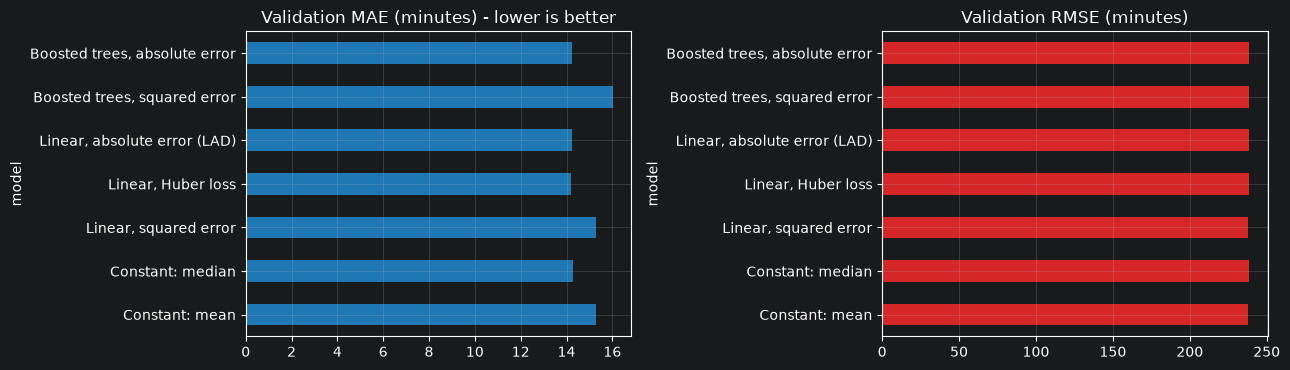

In [12]:
best_name = results["MAE"].idxmin()
print(f"Best validation MAE: {best_name}")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
results["MAE"].plot(kind="barh", ax=axes[0], color="tab:blue")
axes[0].set_title("Validation MAE (minutes) - lower is better")
results["RMSE"].plot(kind="barh", ax=axes[1], color="tab:red")
axes[1].set_title("Validation RMSE (minutes)")
plt.tight_layout()
plt.show()

Three things in that table are worth reading carefully.

**The loss decides the answer, not the model family.** The robust fits — Huber, LAD, and boosted trees with absolute error — land within a few hundredths of a minute of each other on MAE, while both squared-error fits sit clearly worse. Two very different hypothesis spaces agree once they share a loss, which is strong evidence that the loss is what matters here.

**Squared error is worse than predicting a constant.** Boosted trees fitted with squared error do not just underperform, they lose to the constant-median baseline on MAE. Chasing the tail actively damages accuracy on ordinary trips.

**The gain over the baseline is small.** The best model improves on a single constant by well under a percent of MAE. Five coarse features cannot say much about an individual trip; what they capture is a systematic shift in the typical trip, which step 10 shows. Reporting this rather than burying it is part of the result.

RMSE ranks the models almost in reverse, and R² is ~0 for everything. That is expected, not a contradiction: RMSE and R² are squared-error quantities, so they reward exactly the tail-chasing behaviour we set out to avoid.

In [13]:
# What does each model predict for the same ordinary trip?
example = pd.DataFrame([{"hour": 17, "weekday": 2, "month": 7, "temp_c": 18.0, "precip_mm": 0.0}])
predictions = pd.Series(
    {name: float(model.predict(example)[0]) for name, model in fitted.items()},
    name="predicted minutes",
)
print("Wednesday 17:00 in July, 18 C, no rain")
print(f"(actual median duration of comparable trips: {trips.loc[(trips['departure'].dt.hour == 17) & (trips['departure'].dt.dayofweek == 2) & (trips['departure'].dt.month == 7), 'duration_min'].median():.1f} min)")
predictions.to_frame()

Wednesday 17:00 in July, 18 C, no rain
(actual median duration of comparable trips: 11.9 min)


,predicted minutes
Constant: mean,16.65
Constant: median,10.35
"Linear, squared error",15.23
"Linear, Huber loss",11.53
"Linear, absolute error (LAD)",10.90
"Boosted trees, squared error",16.61
"Boosted trees, absolute error",11.37


## 9. Why the loss matters: an outlier-sensitivity experiment

The claim is that squared error is unduly influenced by a handful of forgotten rentals. We can test it directly: refit every model on a training set with the longest 0.1% of trips removed, and see how far each model's predictions move.

A robust method should barely notice. If squared error moves a lot, then those few trips were steering it.

In [14]:
cutoff = y_train.quantile(0.999)
keep = y_train <= cutoff
X_trim, y_trim = X_train[keep], y_train[keep]
print(f"Removed {(~keep).sum():,} trips longer than {cutoff:.0f} min ({(~keep).mean():.2%} of the training sample)")

# A grid of ordinary conditions to compare predictions on.
grid = pd.DataFrame(
    [{"hour": h, "weekday": wd, "month": m, "temp_c": t, "precip_mm": p}
     for h in (8, 12, 17, 22) for wd in (2, 5) for m in (5, 7, 9) for t in (10.0, 20.0) for p in (0.0, 5.0)]
)

sensitivity = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for name, model in build_models().items():
        if name.startswith("Constant"):
            continue
        full_pred = fitted[name].predict(grid)
        trim_pred = model.fit(X_trim, y_trim).predict(grid)
        sensitivity.append({
            "model": name,
            "mean prediction (all data)": full_pred.mean(),
            "mean prediction (0.1% trimmed)": trim_pred.mean(),
            "mean shift": np.abs(full_pred - trim_pred).mean(),
        })

sensitivity = pd.DataFrame(sensitivity).set_index("model")
sensitivity["shift %"] = 100 * sensitivity["mean shift"] / sensitivity["mean prediction (all data)"]
sensitivity

Removed 400 trips longer than 1069 min (0.10% of the training sample)


,mean prediction (all data),mean prediction (0.1% trimmed),mean shift,shift %
model,,,,
"Linear, squared error",16.93,14.00,2.95,17.42
"Linear, Huber loss",10.84,10.82,0.02,0.14
"Linear, absolute error (LAD)",10.11,10.16,0.06,0.60
"Boosted trees, squared error",17.74,13.82,4.10,23.09
"Boosted trees, absolute error",9.97,9.93,0.17,1.71


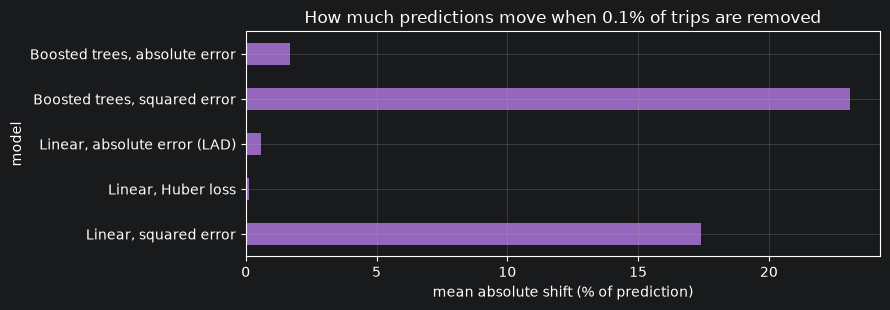

In [15]:
ax = sensitivity["shift %"].plot(kind="barh", figsize=(9, 3.2), color="tab:purple")
ax.set_title("How much predictions move when 0.1% of trips are removed")
ax.set_xlabel("mean absolute shift (% of prediction)")
plt.tight_layout()
plt.show()

The size of the bars is the argument. The squared-error fits shift noticeably when a tiny fraction of the data is removed; the robust fits stay put. That instability is a property of the loss, not of the data cleaning — and it is why we report the robust model as the final one.

## 10. Final evaluation on the test set

We refit the selected model on the training and validation seasons (2022–2024) and evaluate once on the untouched 2025 season.

In [16]:
X_trainval = pd.concat([X_train_full, X_val])
y_trainval = pd.concat([y_train_full, y_val])
sample_tv = X_trainval.sample(TRAIN_SAMPLE, random_state=RANDOM_STATE).index

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    final_model = build_models()[best_name].fit(X_trainval.loc[sample_tv], y_trainval.loc[sample_tv])

y_pred = np.clip(final_model.predict(X_test), 0, None)

# The baseline is refitted the same way, so the comparison is like for like.
baseline = ConstantPredictor("median").fit(X_trainval.loc[sample_tv], y_trainval.loc[sample_tv])
y_base = baseline.predict(X_test)

test_scores = pd.DataFrame(
    [evaluate(y_test, y_pred), evaluate(y_test, y_base)],
    index=[best_name, "Constant: median (baseline)"],
)

print(f"Test season 2025: {len(y_test):,} trips")
print(f"The baseline predicts {baseline.value_:.1f} min for every trip.")
test_scores

Test season 2025: 2,452,061 trips
The baseline predicts 10.6 min for every trip.


,MAE,MedAE,RMSE,R2
"Linear, Huber loss",15.40,5.66,415.43,-0.00
Constant: median (baseline),15.48,5.43,415.45,-0.00


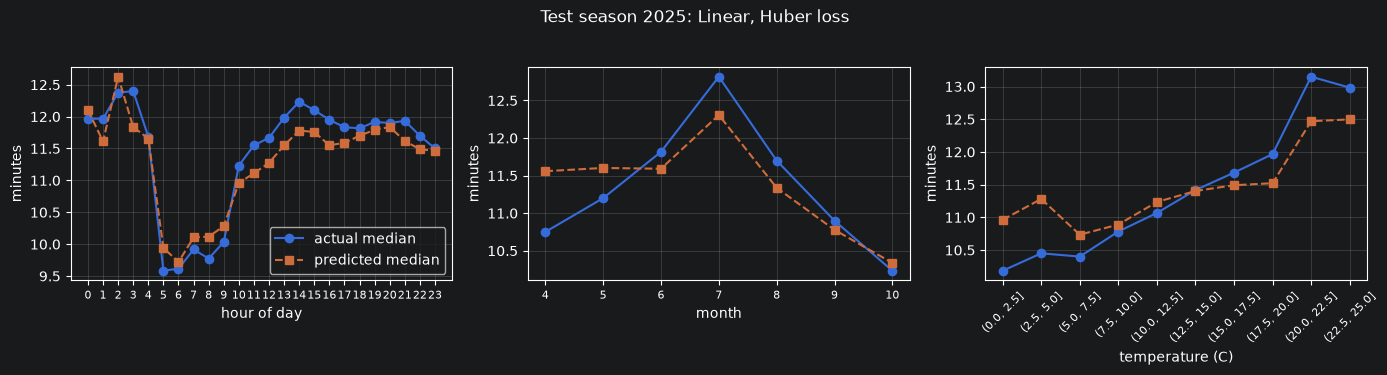

In [17]:
# Does the model track the typical trip across conditions it was not selected on?
pred = pd.Series(y_pred, index=X_test.index)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
for ax, col, label in zip(axes, ["hour", "month", "temp_c"], ["hour of day", "month", "temperature (C)"]):
    grouper = pd.cut(X_test[col], bins=np.arange(-5, 30, 2.5)) if col == "temp_c" else X_test[col]
    actual = y_test.groupby(grouper, observed=True).median()
    predicted = pred.groupby(grouper, observed=True).median()
    ax.plot(range(len(actual)), actual.values, marker="o", label="actual median")
    ax.plot(range(len(predicted)), predicted.values, marker="s", ls="--", label="predicted median")
    ax.set_xticks(range(len(actual)))
    ax.set_xticklabels([str(i) for i in actual.index], rotation=45 if col == "temp_c" else 0, fontsize=8)
    ax.set_xlabel(label)
    ax.set_ylabel("minutes")
axes[0].legend()
fig.suptitle(f"Test season 2025: {best_name}", y=1.03)
plt.tight_layout()
plt.show()

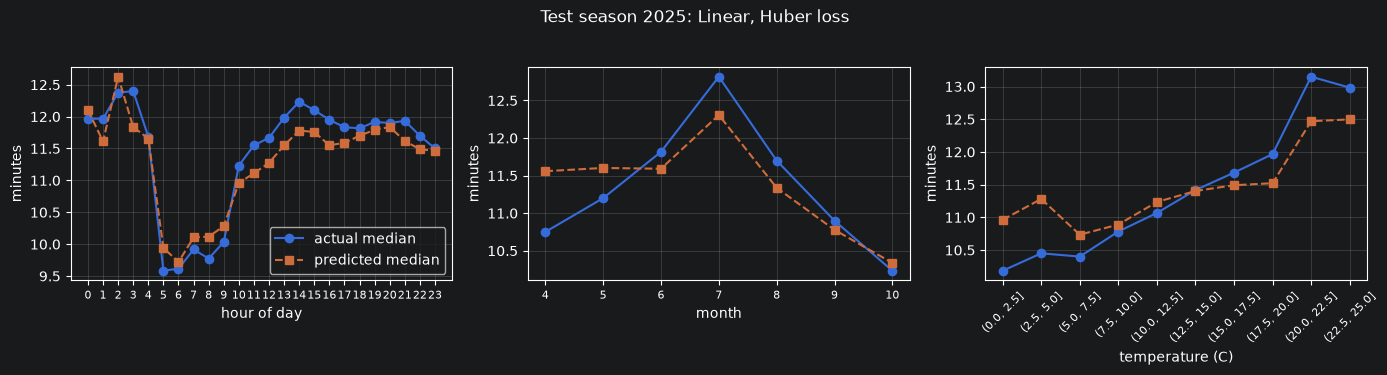

In [18]:
# Does the model track the typical trip across conditions it was not selected on?
pred = pd.Series(y_pred, index=X_test.index)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
for ax, col, label in zip(axes, ["hour", "month", "temp_c"], ["hour of day", "month", "temperature (C)"]):
    grouper = pd.cut(X_test[col], bins=np.arange(-5, 30, 2.5)) if col == "temp_c" else X_test[col]
    actual = y_test.groupby(grouper, observed=True).median()
    predicted = pred.groupby(grouper, observed=True).median()
    ax.plot(range(len(actual)), actual.values, marker="o", label="actual median")
    ax.plot(range(len(predicted)), predicted.values, marker="s", ls="--", label="predicted median")
    ax.set_xticks(range(len(actual)))
    ax.set_xticklabels([str(i) for i in actual.index], rotation=45 if col == "temp_c" else 0, fontsize=8)
    ax.set_xlabel(label)
    ax.set_ylabel("minutes")
axes[0].legend()
fig.suptitle(f"Test season 2025: {best_name}", y=1.03)
plt.tight_layout()
plt.show()

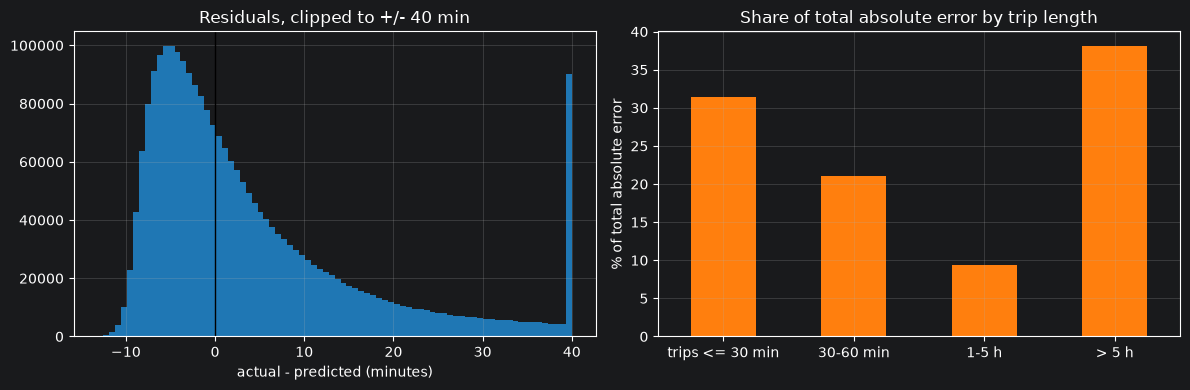

Median absolute error: 5.7 min
Share of test trips predicted within 5 minutes: 44.3%


In [19]:
# Error distribution: where the remaining error comes from.
residuals = y_test - pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(residuals.clip(-40, 40), bins=80, color="tab:blue")
axes[0].axvline(0, color="black", lw=1)
axes[0].set_title("Residuals, clipped to +/- 40 min")
axes[0].set_xlabel("actual - predicted (minutes)")

share = pd.Series({
    "trips <= 30 min": residuals[y_test <= 30].abs().sum(),
    "30-60 min": residuals[(y_test > 30) & (y_test <= 60)].abs().sum(),
    "1-5 h": residuals[(y_test > 60) & (y_test <= 300)].abs().sum(),
    "> 5 h": residuals[y_test > 300].abs().sum(),
})
(100 * share / share.sum()).plot(kind="bar", ax=axes[1], color="tab:orange")
axes[1].set_title("Share of total absolute error by trip length")
axes[1].set_ylabel("% of total absolute error")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

print(f"Median absolute error: {residuals.abs().median():.1f} min")
print(f"Share of test trips predicted within 5 minutes: {(residuals.abs() <= 5).mean():.1%}")

## 11. Conclusions

**On the loss function.** This was the methodological question of the project, and the data answered it clearly.

1. *The outliers are real and they dominate.* Trips over five hours are about 0.3% of the data, yet they account for nearly all of the squared error a least-squares fit minimises (step 5). The longest "trip" in the data runs to thousands of hours — a bike that was never properly returned, not a ride.
2. *Squared error therefore fits the wrong thing.* Both squared-error models predict a duration well above the observed median for ordinary conditions, and boosted trees with squared error are beaten by a constant prediction on MAE (step 8).
3. *The sensitivity experiment confirms the mechanism.* Removing the longest 0.1% of training trips moves the squared-error predictions by roughly 17–23%, while Huber and LAD move by under 2% (step 9). Squared error was being steered by a few hundred forgotten rentals; the robust losses were not.

So the robust loss is not a stylistic preference here — it changes the prediction for an ordinary Wednesday commute by several minutes, in the direction of the observed median. The cost is a real one to state: Huber and LAD estimate a conditional median rather than a mean, so this model must not be used to forecast total system usage time. That question needs the mean, and with it the outlier problem returns — properly handled by first separating forgotten rentals from rides.

**On predictability.** The honest headline is that the chosen model improves on a constant prediction only slightly, and the test season makes that sharper still: the Huber model beats the constant-median baseline on MAE (15.40 vs 15.48 min) but is marginally *worse* on MedAE (5.66 vs 5.43 min). In other words, on 2025 data the calendar and weather features buy a small improvement in average error and nothing at all for the typical trip. A reader should treat the model as evidence about *conditions*, not as a useful per-trip predictor. Weekday, hour, month and daily weather say little about how long *one* trip takes, because that mostly depends on where the rider is going. What these features do capture is the systematic shift in the typical trip — longer in summer, longer at weekends, shorter in rain (steps 6 and 10). The model is a good description of conditions and a weak predictor of individuals, and the evaluation reports it that way rather than hiding behind a metric that happens to look better.

**Limitations and next steps**
- **Daily weather is coarse.** A day with 5 mm of rain may have been dry at 17:00. Hourly FMI observations would sharpen the rain effect, at the cost of a slightly more involved join.
- **No origin or destination.** Station pairs would explain far more variance than any calendar feature, since distance largely determines duration.
- **Long trips are not modelled, only down-weighted.** If the goal were to *detect* forgotten rentals, they would become the label of a classification problem rather than noise to be robust against.
- **Distance as an alternative label.** Setting `TARGET = "distance_km"` in step 1 reruns the whole analysis for distance. Distance has a bounded tail (a forgotten bike sits still), so the robust and squared-error losses should agree much more closely — a useful contrast, and a check that the outlier story above is really about forgotten rentals.